In [1]:
!pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"
!pip install numpy==1.25.2
!pip install --upgrade --force-reinstall pandas

  Cloning https://github.com/ibm-granite/granite-tsfm.git (to revision v0.2.22) to /tmp/pip-install-rdtaf80n/granite-tsfm_f88176bd260c44e59a9e0b339de4ef30
  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git /tmp/pip-install-rdtaf80n/granite-tsfm_f88176bd260c44e59a9e0b339de4ef30
  Running command git checkout -q 216850d0cb073e31689049c1334f701fe11bc2c3
  Resolved https://github.com/ibm-granite/granite-tsfm.git to commit 216850d0cb073e31689049c1334f701fe11bc2c3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 19.5 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.2
    Uninstalling tzdata-2025.2:
      Successfully uninstalled tzdata-2025.2
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1

In [1]:
import os
import tempfile

from transformers import Trainer, TrainingArguments, set_seed

from tsfm_public import TinyTimeMixerForPrediction, load_dataset
from tsfm_public.toolkit import RecursivePredictor, RecursivePredictorConfig
from tsfm_public.toolkit.visualization import plot_predictions
from tsfm_public import TimeSeriesPreprocessor, get_datasets
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
import matplotlib.pyplot as plt

In [3]:
import glob

In [51]:
import numpy as np
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  T,X = T[::100],X[::100]

  return T,X

In [5]:
import torch
from copy import deepcopy

def update_past_values_with_predictions(dset_test, predictions, context_length=512):
  from copy import deepcopy
  import torch

  samples = []


  for i in range(len(dset_test)):
    sample = deepcopy(dset_test[i])
    old_past = sample['past_values']        # shape [512, 1]
    new_vals_np = predictions[i]                     # shape [96, 1] expected
    #print(f"[{i}] pred shape: {new_vals_np.shape}, old tail: {old_past[-1]}")

    new_vals = torch.tensor(new_vals_np, dtype=old_past.dtype)

    combined = torch.cat([old_past, new_vals], dim=0)[-context_length:]

    sample["past_values"] = combined
    samples.append(sample)
  #dset_updated = ForecastDFDataset(data = samples,)
  #print(type(dset_updated))

  return samples

# $\tau = 60$

In [52]:
tau = 60
frac = 75
location = "uniform"
temp_dir = tempfile.mkdtemp()

In [62]:
# fetch the model
model_path = f"./drive/MyDrive/ColabBackup/MG_x0_1_tau_{tau}_{frac}_{location}/output"
matching_dirs = glob.glob(os.path.join(model_path, "checkpoint-*"))
checkpoint_path = matching_dirs[0]
model = TinyTimeMixerForPrediction.from_pretrained(checkpoint_path)
# generate data
T,X = MG_generate_interp(tau=tau,x0 = 1, N = 2000000)

# data preprocessing
MGdata = pd.DataFrame({
    'time': [round(x) for x in T],
    'P': X,
})
timestamp_column_MG = "time"
id_columns_MG = []  # mention the ids that uniquely identify a time-series.

target_columns_MG = ["P"]
split_config_MG = {
    "train": [0, 6000],
    "valid": [6000, 9000],
    "test": [
        12512,
        15000,
    ],
}
column_specifiers_MG = {
    "timestamp_column": timestamp_column_MG,
    "id_columns": id_columns_MG,
    "target_columns": target_columns_MG,
    "control_columns": [],
}
tsp = TimeSeriesPreprocessor(
    **column_specifiers_MG,
    context_length=512,
    prediction_length=96,                          # match your time interval
    scaling=False,
    encode_categorical=False,
    #scaler_type="standard",           # match training
)

# manually scaler

scale_mean = np.zeros(1000)
scale_sd = np.zeros(1000)

for i in range (1000):
  scale_mean[i] = np.mean(X[12000+i:12000+i+512])
  scale_sd[i] = np.std(X[12000+i:12000+i+512])

_, _, dset_test = get_datasets(
    tsp, MGdata, split_config_MG,
    fewshot_fraction=1.0,
    fewshot_location=location
)


# model init
zeroshot_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
        seed = 0,
    ),
)



## TTM_5

In [66]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

In [67]:
# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]

In [68]:
preds = pred
for i in range(210):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0][:,:5,:]
  preds = np.concatenate((preds,pred),axis = 1)

In [69]:
preds = preds.squeeze(-1)
preds_TTM_5 = preds[:,:1024,]

In [70]:
for i in range(100):
  preds_TTM_5[i] = preds_TTM_5[i]*scale_sd[10*i]+scale_mean[10*i]

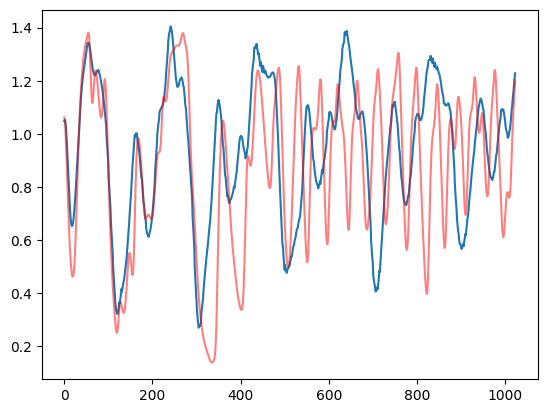

In [72]:
plt.plot(preds_TTM_5[0])
plt.plot(X[12512:13536],color = "red",alpha = 0.5)
plt.show()

In [73]:
import pickle

with open("TTM_5_chaos_test.pkl","wb") as f:
  pickle.dump(preds_TTM_5,f)

## TTM_short


In [74]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]

preds = pred
for i in range(12):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0][:,:(96-3*i),:]
  preds = np.concatenate((preds,pred),axis = 1)

preds = preds.squeeze(-1)

preds_TTM_dege = preds[:,:1024,]



In [75]:
for i in range(100):
  preds_TTM_dege[i] = preds_TTM_dege[i]*scale_sd[10*i]+scale_mean[10*i]

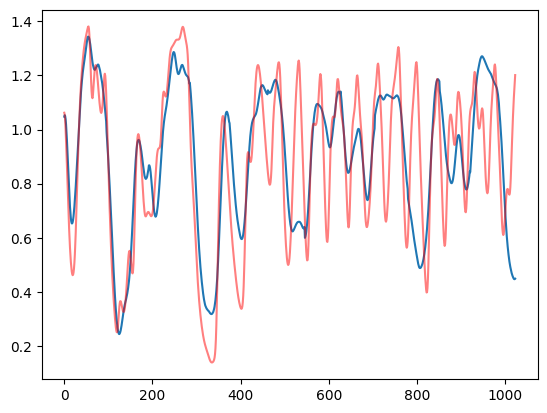

In [76]:
plt.plot(preds_TTM_dege[0])
plt.plot(X[12512:13536],color = "red",alpha = 0.5)
plt.show()

In [77]:
import pickle

with open("TTM_dege_chaos_test.pkl","wb") as f:
  pickle.dump(preds_TTM_dege,f)

## TTM

In [63]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]

preds = pred
for i in range(11):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0]
  preds = np.concatenate((preds,pred),axis = 1)

preds = preds.squeeze(-1)

preds_TTM = preds[:,:1024,]

for i in range(100):
  preds_TTM[i] = preds_TTM[i]*scale_sd[10*i]+scale_mean[10*i]

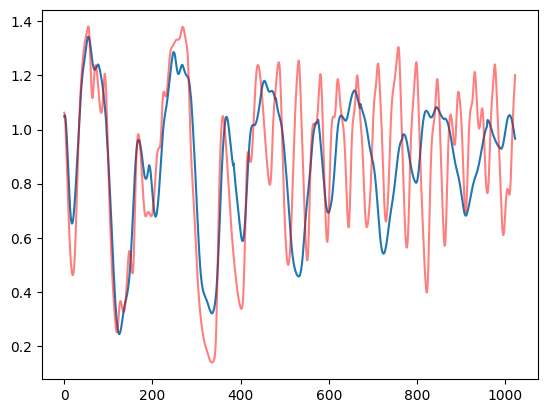

In [64]:
plt.plot(preds_TTM[0])
plt.plot(X[12512:13536],color = "red",alpha = 0.5)
plt.show()

In [65]:
import pickle

with open("TTM_chaos_test.pkl","wb") as f:
  pickle.dump(preds_TTM,f)

# $\tau = 200$

In [99]:
tau = 200
frac = 75
location = "uniform"
temp_dir = tempfile.mkdtemp()

In [100]:
# fetch the model
model_path = f"./drive/MyDrive/ColabBackup/MG_x0_1_tau_{tau}_{frac}_{location}/output"
matching_dirs = glob.glob(os.path.join(model_path, "checkpoint-*"))
checkpoint_path = matching_dirs[0]
model = TinyTimeMixerForPrediction.from_pretrained(checkpoint_path)
# generate data
T,X = MG_generate_interp(tau=tau,x0 = 1, N = 2000000)

# data preprocessing
MGdata = pd.DataFrame({
    'time': [round(x) for x in T],
    'P': X,
})
timestamp_column_MG = "time"
id_columns_MG = []  # mention the ids that uniquely identify a time-series.

target_columns_MG = ["P"]
split_config_MG = {
    "train": [0, 6000],
    "valid": [6000, 9000],
    "test": [
        12512,
        15000,
    ],
}
column_specifiers_MG = {
    "timestamp_column": timestamp_column_MG,
    "id_columns": id_columns_MG,
    "target_columns": target_columns_MG,
    "control_columns": [],
}
tsp = TimeSeriesPreprocessor(
    **column_specifiers_MG,
    context_length=512,
    prediction_length=96,                          # match your time interval
    scaling=False,
    encode_categorical=False,
    #scaler_type="standard",           # match training
)

# manually scaler

scale_mean = np.zeros(1000)
scale_sd = np.zeros(1000)

for i in range (1000):
  scale_mean[i] = np.mean(X[12000+i:12000+i+512])
  scale_sd[i] = np.std(X[12000+i:12000+i+512])

_, _, dset_test = get_datasets(
    tsp, MGdata, split_config_MG,
    fewshot_fraction=1.0,
    fewshot_location=location
)


# model init
zeroshot_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
        seed = 0,
    ),
)



## TTM_5

In [101]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]
preds = pred
for i in range(210):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0][:,:5,:]
  preds = np.concatenate((preds,pred),axis = 1)

preds = preds.squeeze(-1)
preds_TTM_5_200 = preds[:,:1024,]

for i in range(100):
  preds_TTM_5_200[i] = preds_TTM_5_200[i]*scale_sd[10*i]+scale_mean[10*i]

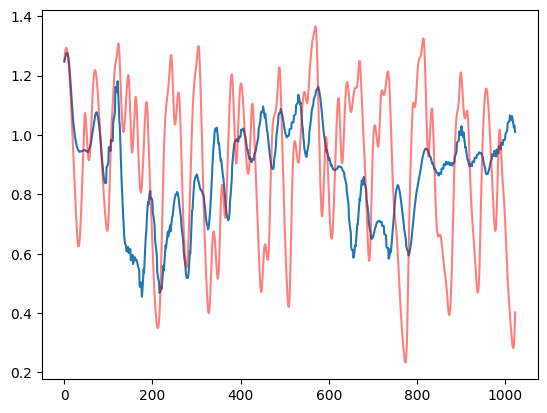

In [113]:
plt.plot(preds_TTM_5_200[0])
plt.plot(X[12512:13536],color = "red",alpha = 0.5)
plt.show()

In [114]:
import pickle

with open("TTM_5_chaos_test_200.pkl","wb") as f:
  pickle.dump(preds_TTM_5_200,f)

## TTM_short

In [106]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]

preds = pred
for i in range(12):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0][:,:(96-3*i),:]
  preds = np.concatenate((preds,pred),axis = 1)

preds = preds.squeeze(-1)

preds_TTM_dege_200 = preds[:,:1024,]

for i in range(100):
  preds_TTM_dege_200[i] = preds_TTM_dege_200[i]*scale_sd[10*i]+scale_mean[10*i]

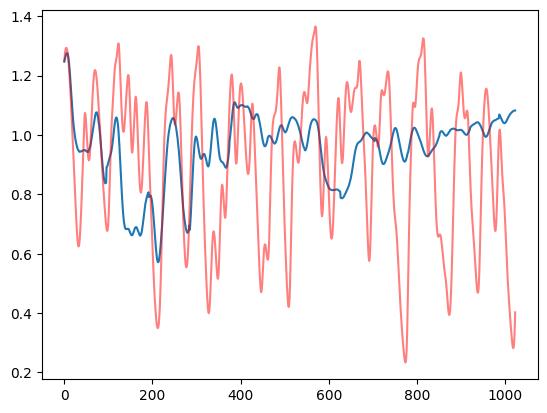

In [107]:
plt.plot(preds_TTM_dege_200[0])
plt.plot(X[(12512):(13536)],color = "red",alpha = 0.5)
plt.show()

In [108]:
import pickle

with open("TTM_dege_chaos_test_200.pkl","wb") as f:
  pickle.dump(preds_TTM_dege_200,f)

## TTM

In [109]:
dset_test_sc =[]
for i in range(100):
  data_test_sc = deepcopy(dset_test[10*i])
  data_test_sc['past_values'] = (dset_test[10*i]['past_values']-scale_mean[10*i])/scale_sd[10*i]
  data_test_sc['future_values'] = (dset_test[10*i]['future_values']-scale_mean[10*i])/scale_sd[10*i]
  dset_test_sc.append(data_test_sc)

# first predction
predictions_dict_first = zeroshot_trainer.predict(dset_test_sc)
pred = predictions_dict_first.predictions[0]

preds = pred
for i in range(11):
  dset_test_sc = update_past_values_with_predictions(dset_test_sc, pred)
  predictions_dict = zeroshot_trainer.predict(dset_test_sc)
  pred = predictions_dict.predictions[0]
  preds = np.concatenate((preds,pred),axis = 1)

preds = preds.squeeze(-1)

preds_TTM_200 = preds[:,:1024,]

for i in range(100):
  preds_TTM_200[i] = preds_TTM_200[i]*scale_sd[10*i]+scale_mean[10*i]

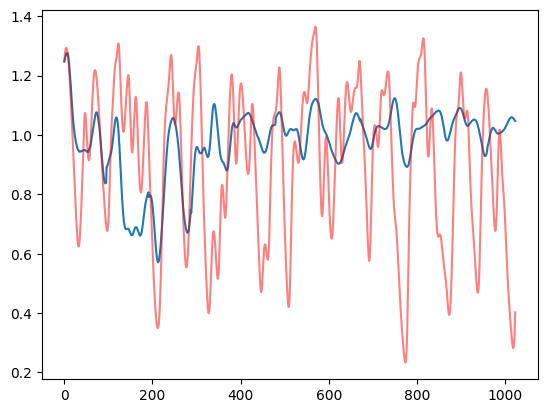

In [110]:
plt.plot(preds_TTM_200[0])
plt.plot(X[12512:13536],color = "red",alpha = 0.5)
plt.show()

In [115]:
import pickle

with open("TTM_chaos_test_200.pkl","wb") as f:
  pickle.dump(preds_TTM_200,f)